# TMB Classification from Whole-Slide Images

This notebook performs Tumor Mutational Burden (TMB) classification from histopathology images using a CNN model.

In [1]:
!wget https://gdc.cancer.gov/files/public/file/gdc-client_v1.6.1_Ubuntu_x64.zip
!unzip gdc-client*.zip

--2026-04-24 23:13:56--  https://gdc.cancer.gov/files/public/file/gdc-client_v1.6.1_Ubuntu_x64.zip
Resolving gdc.cancer.gov (gdc.cancer.gov)... 67.202.18.12, 52.203.187.172
Connecting to gdc.cancer.gov (gdc.cancer.gov)|67.202.18.12|:443... connected.
HTTP request sent, awaiting response... 302 Moved Temporarily
Location: https://gdc.cancer.gov:443/system/files/public/file/gdc-client_v1.6.1_Ubuntu_x64.zip [following]
--2026-04-24 23:13:56--  https://gdc.cancer.gov/system/files/public/file/gdc-client_v1.6.1_Ubuntu_x64.zip
Reusing existing connection to gdc.cancer.gov:443.
HTTP request sent, awaiting response... 200 OK
Length: 23940006 (23M) [application/zip]
Saving to: ‘gdc-client_v1.6.1_Ubuntu_x64.zip’

gdc-client_v1.6.1_U 100%[===================>]  22.83M  32.3MB/s    in 0.7s    

2026-04-24 23:13:57 (32.3 MB/s) - ‘gdc-client_v1.6.1_Ubuntu_x64.zip’ saved [23940006/23940006]

Archive:  gdc-client_v1.6.1_Ubuntu_x64.zip
 extracting: gdc-client              


## 1. Download Genomic Data

Download MAF files from the GDC (Genomic Data Commons) to extract TMB counts.

In [2]:
from google.colab import files
files.upload()

Saving gdc_manifest.2026-04-25.001209.txt to gdc_manifest.2026-04-25.001209.txt


{'gdc_manifest.2026-04-25.001209.txt': b'id\tfilename\tmd5\tsize\tstate\n09fefec2-4650-459d-9eb6-8c0fb2a958e9\tb55b2a17-a83f-4a3e-a920-d3282d849f1a.wxs.aliquot_ensemble_masked.maf.gz\te0a9d1cc791d0502e6323a1fe7b30bd6\t475317\treleased\n39495aca-acc5-417a-8679-22e9246e77c0\tb5e17cd3-950b-4bf5-863b-936f5fb10f42.wxs.aliquot_ensemble_masked.maf.gz\t42d6aa64cd2003d3ef3714e3668ba660\t40689\treleased\n8091fa97-b1d1-41cf-8d04-9de39b9527a5\t5362a2ba-0512-478c-8f56-cd234c701a64.wxs.aliquot_ensemble_masked.maf.gz\tf4c584c4b324f09eda4c8aba697f810f\t1071247\treleased\n2ea37d59-7910-4644-93d2-61c1aaa4a528\t8657c2c9-05b5-4ddd-a481-6447dfdfedb4.wxs.aliquot_ensemble_masked.maf.gz\tc821de80e26e861a3957e19c51fa5540\t172092\treleased\n6d5f1f85-2ded-4b3d-8ea4-3029570d9bbf\t999494ec-f78c-4001-a8cd-7d969bceafc3.wxs.aliquot_ensemble_masked.maf.gz\t98216c2742f8187035a608ed02b6f782\t62410\treleased\nbe0a9525-3580-454a-9918-fd514320724f\t97db3ed5-1991-452f-9157-1f2b2667c802.wxs.aliquot_ensemble_masked.maf.gz\t84

In [3]:
!./gdc-client download -m gdc_manifest.2026-04-25.001209.txt

100% [#############################################] Time:  0:00:01 719.7 KiB/s 
100% [#############################################] Time:  0:00:01  29.0 KiB/s 
100% [#############################################] Time:  0:00:00  78.1 KiB/s 
100% [#############################################] Time:  0:00:00  21.8 KiB/s 
100% [#############################################] Time:  0:00:00  89.8 KiB/s 
100% [#############################################] Time:  0:00:00  88.2 KiB/s 
100% [#############################################] Time:  0:00:01 610.8 KiB/s 
100% [#############################################] Time:  0:00:00   9.4 KiB/s 
100% [#############################################] Time:  0:00:00  39.4 KiB/s 
100% [#############################################] Time:  0:00:00  30.7 KiB/s 
100% [#############################################] Time:  0:00:00 172.7 KiB/s 
100% [#############################################] Time:  0:00:00  84.5 KiB/s 
100% [######################

In [4]:
import os

for f in os.listdir():
    print(f)

.config
39495aca-acc5-417a-8679-22e9246e77c0
18eb3e5b-a608-4cdf-a8e7-afc181c456e6
2ea37d59-7910-4644-93d2-61c1aaa4a528
cd5b5bb7-4e91-4c25-803c-6184dacb930b
147c007c-af86-49db-8c4b-568ea0c176ad
144983c0-174b-45c1-90c3-327e217ce685
dd43c47d-0bde-406c-ae96-7268489f362e
gdc-client_v1.6.1_Ubuntu_x64.zip
gdc_manifest.2026-04-25.001209.txt
df4bd1d4-36c1-4819-8e7d-3a684cb70824
5843bc08-274a-42ff-b344-104efdbe5df7
8091fa97-b1d1-41cf-8d04-9de39b9527a5
6d5f1f85-2ded-4b3d-8ea4-3029570d9bbf
09fefec2-4650-459d-9eb6-8c0fb2a958e9
gdc-client
da55c4e8-daf2-4c50-9f12-8fc5346378e6
be0a9525-3580-454a-9918-fd514320724f
5712617c-7d35-4397-93ea-bc44cf36884e
9265a913-d5ef-4abc-8ae6-e3a959cdc166
49e0a151-9f01-4a4a-a5c4-7a30bd921c2b
56b15d05-fccd-4928-9d29-b0474513fdb7
f82fb4a9-40b8-430f-b47d-9347f392a9b7
93e3ac46-24ad-423b-ae4b-8a1fbefffce9
sample_data


## 2. Extract TMB Labels

Extract TMB mutation counts from MAF files and create binary labels based on median threshold.

In [5]:
maf_files = []

for root, dirs, files in os.walk("."):
    for file in files:
        if file.endswith(".maf.gz"):
            maf_files.append(os.path.join(root, file))

print("number of files: ", len(maf_files))
print(maf_files[:2])

number of files:  20
['./39495aca-acc5-417a-8679-22e9246e77c0/b5e17cd3-950b-4bf5-863b-936f5fb10f42.wxs.aliquot_ensemble_masked.maf.gz', './18eb3e5b-a608-4cdf-a8e7-afc181c456e6/c83694b4-bd03-430c-8304-9847ea9e68da.wxs.aliquot_ensemble_masked.maf.gz']


In [6]:
import pandas as pd

df = pd.read_csv(maf_files[0], sep="\t", comment="#", compression="gzip")

df.head()

,Hugo_Symbol,Entrez_Gene_Id,Center,NCBI_Build,Chromosome,Start_Position,End_Position,Strand,Variant_Classification,Variant_Type,...,normal_bam_uuid,case_id,GDC_FILTER,COSMIC,hotspot,RNA_Support,RNA_depth,RNA_ref_count,RNA_alt_count,callers
0,NOC2L,26155,BCM,GRCh38,chr1,955922,955922,+,Splice_Site,SNP,...,34e15876-cc86-48e7-8b7f-1dd482c717ec,e703af88-c05f-4d7b-b225-d640e4d1a2a5,NonExonic,COSM1344690,N,Unknown,NaN,NaN,NaN,muse;mutect2;varscan2
1,KIF1B,23095,BCM,GRCh38,chr1,10296993,10296993,+,Missense_Mutation,SNP,...,34e15876-cc86-48e7-8b7f-1dd482c717ec,e703af88-c05f-4d7b-b225-d640e4d1a2a5,NaN,NaN,N,Unknown,NaN,NaN,NaN,muse;mutect2
2,IFNLR1,163702,BCM,GRCh38,chr1,24157197,24157197,+,Missense_Mutation,SNP,...,34e15876-cc86-48e7-8b7f-1dd482c717ec,e703af88-c05f-4d7b-b225-d640e4d1a2a5,NaN,NaN,N,Unknown,NaN,NaN,NaN,muse;mutect2
3,CNKSR1,10256,BCM,GRCh38,chr1,26187447,26187447,+,Missense_Mutation,SNP,...,34e15876-cc86-48e7-8b7f-1dd482c717ec,e703af88-c05f-4d7b-b225-d640e4d1a2a5,NaN,NaN,N,Unknown,NaN,NaN,NaN,muse;mutect2;varscan2
4,ARID1A,8289,BCM,GRCh38,chr1,26779167,26779167,+,Missense_Mutation,SNP,...,34e15876-cc86-48e7-8b7f-1dd482c717ec,e703af88-c05f-4d7b-b225-d640e4d1a2a5,NaN,NaN,N,Unknown,NaN,NaN,NaN,muse;mutect2;varscan2


In [7]:
import pandas as pd
import gzip

tmb_counts = {}

for f in maf_files:
    df = pd.read_csv(f, sep="\t", comment="#", compression="gzip")

    # patient id
    df["patient"] = df["Tumor_Sample_Barcode"].str[:12]


    counts = df.groupby("patient").size()

    for p, c in counts.items():
        tmb_counts[p] = tmb_counts.get(p, 0) + c

In [8]:
import numpy as np

values = np.array(list(tmb_counts.values()))

threshold = np.median(values)  # أو 10 أو percentile

labels = {
    p: 1 if t >= threshold else 0
    for p, t in tmb_counts.items()
}

In [9]:
def get_patient_id(filename):
    return filename[:12]

In [10]:
patients = list(labels.keys())

In [11]:
patients

['TCGA-AZ-4616',
 'TCGA-A6-5665',
 'TCGA-F4-6703',
 'TCGA-CK-4950',
 'TCGA-AA-3560',
 'TCGA-3L-AA1B',
 'TCGA-D5-6534',
 'TCGA-A6-6648',
 'TCGA-AA-3819',
 'TCGA-AA-3510',
 'TCGA-CA-6716',
 'TCGA-AZ-4313',
 'TCGA-DM-A28A',
 'TCGA-F4-6809',
 'TCGA-AA-3975',
 'TCGA-CM-5344',
 'TCGA-AA-3526',
 'TCGA-AA-3695',
 'TCGA-AA-3850',
 'TCGA-CK-4952']

In [12]:
from google.colab import files
files.upload()

Saving gdc_manifest.2026-04-25.011937.txt to gdc_manifest.2026-04-25.011937.txt


{'gdc_manifest.2026-04-25.011937.txt': b'id\tfilename\tmd5\tsize\tstate\nd65c5d21-6333-4a9e-9a2a-139a122a3c8a\tTCGA-AZ-4313-01Z-00-DX1.5e7ecf69-d1fd-4997-9dcc-ab8e9f10b423.svs\t4e9750d2fd3ce0704429cb413feeed12\t664882033\treleased\n940f86d9-850e-4959-b3e7-ea63b1d2588a\tTCGA-F4-6809-01Z-00-DX1.5ab8333f-0c77-4685-8701-4130a93e6f3a.svs\t2ff187413ea759bfbe1fa25c92fe5ad1\t530791857\treleased\n263abaf6-c5a1-4215-8dd5-a8b2a7bfd745\tTCGA-3L-AA1B-01Z-00-DX2.17CE3683-F4B1-4978-A281-8F620C4D77B4.svs\t403aa378ff8655f8328d314b758c9756\t739685437\treleased\n492e492d-6ab5-4fa7-97e1-9b1553d4337b\tTCGA-AA-3526-01Z-00-DX1.82876320-2866-4ffa-81d7-3278f7150fc3.svs\t229f6d193a2880e067e0d99d41a319c5\t356122786\treleased\ncd7bddd5-0f09-4891-a11a-b18cae6b9b53\tTCGA-AA-3819-01Z-00-DX1.cd674efa-b953-4721-9468-ec6ad8b6f567.svs\t25be495b11fe29fefab7d3d94ca7fc5b\t237808674\treleased\n363a0302-d11f-423a-adc6-e324dd65312b\tTCGA-A6-6648-01Z-00-DX1.88b9a490-0bed-43f3-bd74-1bf2810f6884.svs\tc2d5d1773a2d3619ba2a75254a7f

In [13]:
!./gdc-client download -m gdc_manifest.2026-04-25.011937.txt

100% [#############################################] Time:  0:01:11  16.4 MiB/s 
100% [#############################################] Time:  0:00:40  16.3 MiB/s 
100% [#############################################] Time:  0:00:01   5.0 MiB/s 
100% [#############################################] Time:  0:00:30  15.1 MiB/s 
100% [#############################################] Time:  0:00:15  15.6 MiB/s 
100% [#############################################] Time:  0:01:00  15.9 MiB/s 
100% [#############################################] Time:  0:00:12  14.8 MiB/s 
100% [#############################################] Time:  0:00:40  16.0 MiB/s 
100% [#############################################] Time:  0:00:46  16.2 MiB/s 
100% [#############################################] Time:  0:00:06  13.7 MiB/s 
100% [#############################################] Time:  0:01:27  16.5 MiB/s 
100% [#############################################] Time:  0:00:22  16.1 MiB/s 
100% [######################

In [14]:
import os

svs_files = []

for root, dirs, files in os.walk("."):
    for f in files:
        if f.endswith(".svs"):
            svs_files.append(os.path.join(root, f))

print(len(svs_files))

21


In [15]:
def get_patient_id(path):
    return os.path.basename(path)[:12]

dataset = [
    {
        "image": img,
        "label": labels[get_patient_id(img)]
    }
    for img in svs_files
    if get_patient_id(img) in labels
]

print(len(dataset))

21


In [16]:
!apt-get install libopenslide0


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  libopenslide0
0 upgraded, 1 newly installed, 0 to remove and 42 not upgraded.
Need to get 89.8 kB of archives.
After this operation, 223 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libopenslide0 amd64 3.4.1+dfsg-5build1 [89.8 kB]
Fetched 89.8 kB in 1s (179 kB/s)
Selecting previously unselected package libopenslide0.
(Reading database ... 122354 files and directories currently installed.)
Preparing to unpack .../libopenslide0_3.4.1+dfsg-5build1_amd64.deb ...
Unpacking libopenslide0 (3.4.1+dfsg-5build1) ...
Setting up libopenslide0 (3.4.1+dfsg-5build1) ...
Processing triggers for libc-bin (2.35-0ubuntu3.8) ...
/sbin/ldconfig.real: /usr/local/lib/libtcm.so.1 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libtbbbind.so.3 is not a symbolic link

/sbin/ldconfig.real: /usr/local/l

## 3. Download and Extract Patches from WSI

Download whole-slide images (SVS) and extract patches for model training.

In [17]:
!pip install openslide-python

In [18]:
import openslide
import numpy as np

def get_patches(path, size=224):
    slide = openslide.OpenSlide(path)
    w, h = slide.dimensions

    patches = []

    for x in range(0, w, size):
        for y in range(0, h, size):
            patch = slide.read_region((x, y), 0, (size, size))
            patch = np.array(patch)[:, :, :3]
            patches.append(patch)

    return patches

In [19]:
def extract_patches(slide_path, patch_size=224, max_patches=50):
    import openslide
    import numpy as np

    slide = openslide.OpenSlide(slide_path)
    w, h = slide.dimensions

    patches = []
    count = 0

    for x in range(0, w, patch_size):
        for y in range(0, h, patch_size):
            patch = slide.read_region((x, y), 0, (patch_size, patch_size))
            patch = np.array(patch)[:, :, :3]

            if patch.mean() < 220:
                patches.append(patch)
                count += 1

            if count >= max_patches:
                break
        if count >= max_patches:
            break

    return patches

In [20]:
import random

def extract_patches_fast(slide_path, patch_size=224, max_patches=20):
    import openslide
    import numpy as np

    slide = openslide.OpenSlide(slide_path)
    w, h = slide.dimensions

    patches = []

    for _ in range(max_patches):
        x = random.randint(0, w - patch_size)
        y = random.randint(0, h - patch_size)

        patch = slide.read_region((x, y), 0, (patch_size, patch_size))
        patch = np.array(patch)[:, :, :3]

        patches.append(patch)

    return patches

In [21]:
X = []
y = []

for i, item in enumerate(dataset):
    print(f"Processing image {i+1}/{len(dataset)}")

    patches = extract_patches(item["image"])

    for p in patches:
        X.append(p)
        y.append(item["label"])

print(len(X), len(y))

Processing image 1/21
Processing image 2/21
Processing image 3/21
Processing image 4/21
Processing image 5/21
Processing image 6/21
Processing image 7/21
Processing image 8/21
Processing image 9/21
Processing image 10/21
Processing image 11/21
Processing image 12/21
Processing image 13/21
Processing image 14/21
Processing image 15/21
Processing image 16/21
Processing image 17/21
Processing image 18/21
Processing image 19/21
Processing image 20/21
Processing image 21/21
1050 1050


In [23]:
import torch
from torch.utils.data import Dataset, DataLoader

## 4. Data Preparation: Dataset and DataLoaders

Define PyTorch Dataset and create data loaders with train/test split (90/10).

In [24]:
class PatchDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = torch.tensor(self.X[idx]).permute(2,0,1).float() / 255.0
        y = torch.tensor(self.y[idx]).long()
        return x, y

In [25]:
from sklearn.model_selection import train_test_split

# Split into train (90%) and test (10%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.1,
    random_state=42,
    stratify=y
)

print(f"Train samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"Train label distribution: {np.bincount(y_train)}")
print(f"Test label distribution: {np.bincount(y_test)}")

# Create datasets and dataloaders
train_loader = DataLoader(
    PatchDataset(X_train, y_train),
    batch_size=16,
    shuffle=True
)

test_loader = DataLoader(
    PatchDataset(X_test, y_test),
    batch_size=16,
    shuffle=False
)

Train samples: 945
Test samples: 105
Train label distribution: [450 495]
Test label distribution: [50 55]


In [26]:
import torch.nn as nn

class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1)
        )

        self.classifier = nn.Linear(128, 2)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

## 5. Model Definition

Define a simple CNN architecture for patch classification.

In [27]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = CNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [28]:
from sklearn.metrics import accuracy_score

In [31]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = CNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# Track metrics
train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []

num_epochs = 100

for epoch in range(num_epochs):
    # Training phase
    model.train()
    train_loss = 0
    train_preds = []
    train_labels = []

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        pred = model(x)
        loss = criterion(pred, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        preds = torch.argmax(pred, dim=1)
        train_preds.extend(preds.cpu().numpy())
        train_labels.extend(y.cpu().numpy())

    avg_train_loss = train_loss / len(train_loader)
    train_acc = accuracy_score(train_labels, train_preds)
    train_losses.append(avg_train_loss)
    train_accuracies.append(train_acc)

    # Validation phase
    model.eval()
    test_loss = 0
    test_preds = []
    test_labels = []

    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)

            pred = model(x)
            loss = criterion(pred, y)

            test_loss += loss.item()
            preds = torch.argmax(pred, dim=1)
            test_preds.extend(preds.cpu().numpy())
            test_labels.extend(y.cpu().numpy())

    avg_test_loss = test_loss / len(test_loader)
    test_acc = accuracy_score(test_labels, test_preds)
    test_losses.append(avg_test_loss)
    test_accuracies.append(test_acc)

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{num_epochs}")
        print(f"  Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"  Test Loss:  {avg_test_loss:.4f} | Test Acc:  {test_acc:.4f}")

print("\nTraining completed!")


Epoch 5/100
  Train Loss: 0.6227 | Train Acc: 0.6423
  Test Loss:  0.6807 | Test Acc:  0.5238
Epoch 10/100
  Train Loss: 0.5835 | Train Acc: 0.6984
  Test Loss:  0.6339 | Test Acc:  0.5810
Epoch 15/100
  Train Loss: 0.5692 | Train Acc: 0.7079
  Test Loss:  0.6120 | Test Acc:  0.6571
Epoch 20/100
  Train Loss: 0.5500 | Train Acc: 0.6942
  Test Loss:  0.5770 | Test Acc:  0.7524
Epoch 25/100
  Train Loss: 0.5399 | Train Acc: 0.7206
  Test Loss:  0.5599 | Test Acc:  0.7333
Epoch 30/100
  Train Loss: 0.5480 | Train Acc: 0.7217
  Test Loss:  0.5402 | Test Acc:  0.7238
Epoch 35/100
  Train Loss: 0.5275 | Train Acc: 0.7217
  Test Loss:  0.5346 | Test Acc:  0.7429
Epoch 40/100
  Train Loss: 0.4938 | Train Acc: 0.7492
  Test Loss:  0.5058 | Test Acc:  0.7619
Epoch 45/100
  Train Loss: 0.4805 | Train Acc: 0.7407
  Test Loss:  0.5709 | Test Acc:  0.6762
Epoch 50/100
  Train Loss: 0.4916 | Train Acc: 0.7344
  Test Loss:  0.4887 | Test Acc:  0.7714
Epoch 55/100
  Train Loss: 0.4960 | Train Acc: 0.74

In [32]:
# Get final predictions on the entire test set
model.eval()
test_preds_final = []
test_probs_final = []
test_labels_final = []

with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        pred = model(x)
        probs = torch.softmax(pred, dim=1)

        test_preds_final.extend(torch.argmax(pred, dim=1).cpu().numpy())
        test_probs_final.extend(probs[:, 1].cpu().numpy())  # Probability of class 1
        test_labels_final.extend(y.cpu().numpy())

print(f"\nFinal predictions computed on {len(test_labels_final)} test samples")


Final predictions computed on 105 test samples


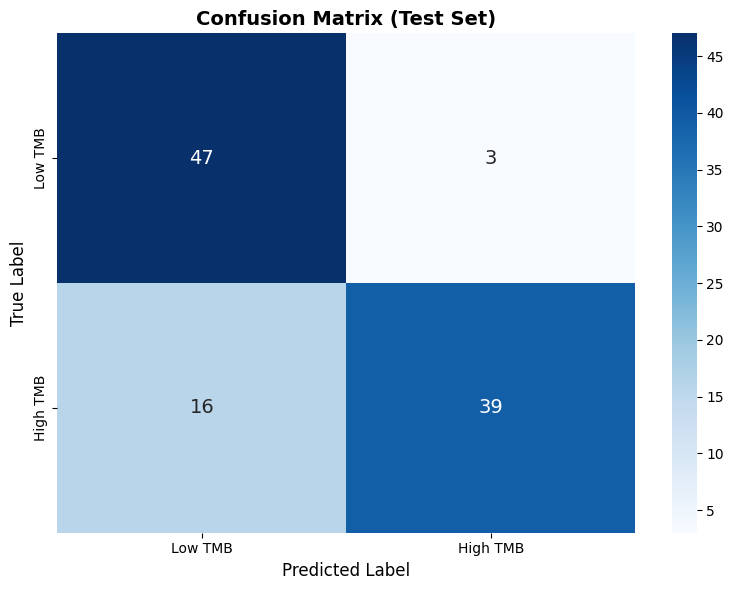

Classification Report:
              precision    recall  f1-score   support

     Low TMB       0.75      0.94      0.83        50
    High TMB       0.93      0.71      0.80        55

    accuracy                           0.82       105
   macro avg       0.84      0.82      0.82       105
weighted avg       0.84      0.82      0.82       105


Test Set Metrics:
  Precision: 0.9286
  Recall:    0.7091
  F1-Score:  0.8041


In [36]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Compute confusion matrix
cm = confusion_matrix(test_labels_final, test_preds_final)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['Low TMB', 'High TMB'],
            yticklabels=['Low TMB', 'High TMB'],
            annot_kws={'size': 14})
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix (Test Set)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print classification report
print("Classification Report:")
print(classification_report(test_labels_final, test_preds_final,
                          target_names=['Low TMB', 'High TMB']))

# Print additional metrics
from sklearn.metrics import precision_score, recall_score, f1_score
precision = precision_score(test_labels_final, test_preds_final)
recall = recall_score(test_labels_final, test_preds_final)
f1 = f1_score(test_labels_final, test_preds_final)

print(f"\nTest Set Metrics:")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1-Score:  {f1:.4f}")

## 9. Confusion Matrix (Test Set)

Compute and visualize confusion matrix for test set predictions.

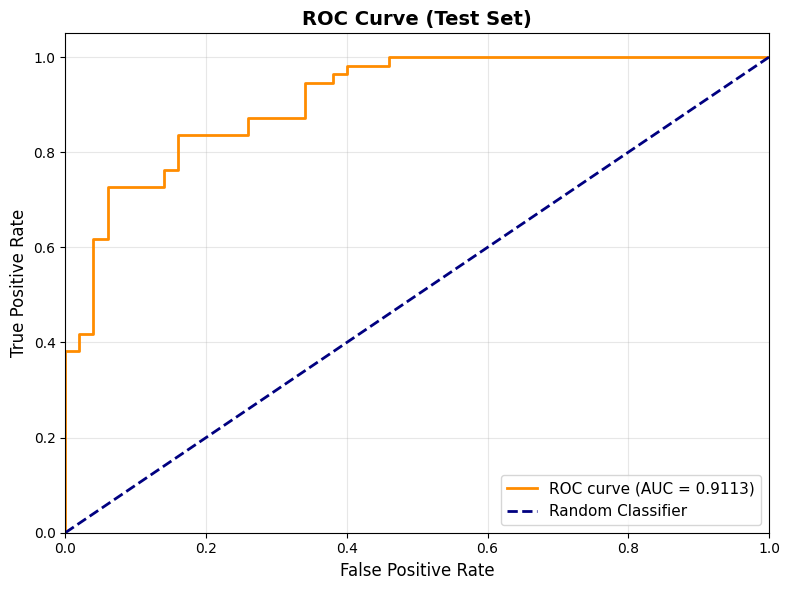

ROC AUC Score: 0.9113


In [37]:
from sklearn.metrics import roc_curve, auc, roc_auc_score

# Get predictions and probabilities on test set
model.eval()
test_preds_final = []
test_probs_final = []
test_labels_final = []

with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        pred = model(x)
        probs = torch.softmax(pred, dim=1)

        test_preds_final.extend(torch.argmax(pred, dim=1).cpu().numpy())
        test_probs_final.extend(probs[:, 1].cpu().numpy())  # Probability of class 1
        test_labels_final.extend(y.cpu().numpy())

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(test_labels_final, test_probs_final)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve (Test Set)', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"ROC AUC Score: {roc_auc:.4f}")

## 8. ROC Curve (Test Set)

Compute and visualize ROC curve for test set predictions.

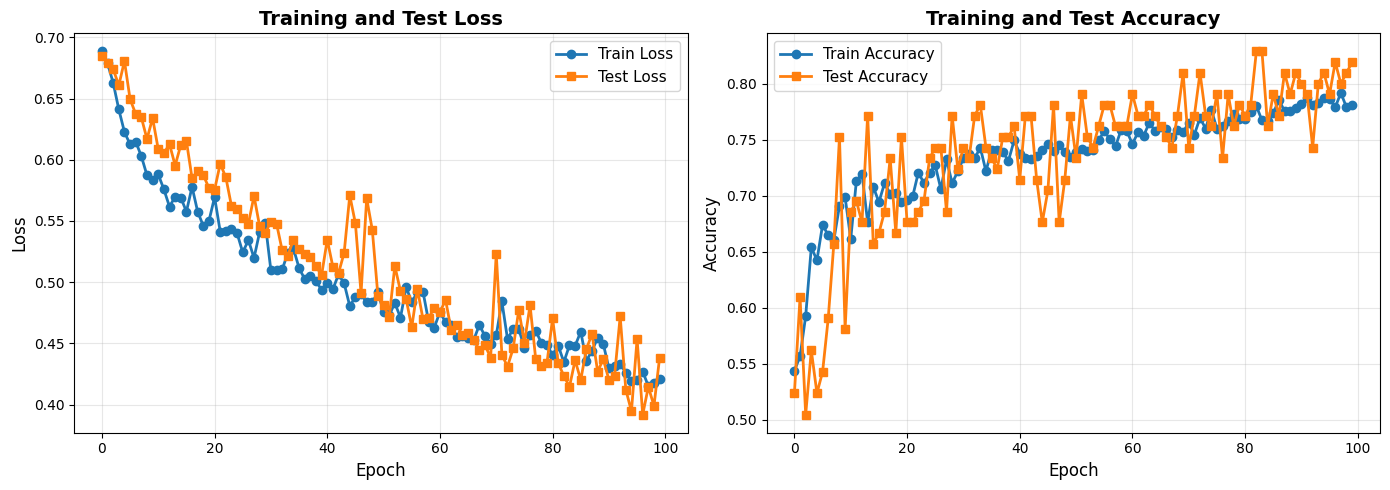

Best Test Accuracy: 0.8286 at Epoch 83
Final Test Accuracy: 0.8190


In [35]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Loss
axes[0].plot(train_losses, label='Train Loss', marker='o', linewidth=2)
axes[0].plot(test_losses, label='Test Loss', marker='s', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training and Test Loss', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Plot Accuracy
axes[1].plot(train_accuracies, label='Train Accuracy', marker='o', linewidth=2)
axes[1].plot(test_accuracies, label='Test Accuracy', marker='s', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Training and Test Accuracy', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Best Test Accuracy: {max(test_accuracies):.4f} at Epoch {test_accuracies.index(max(test_accuracies))+1}")
print(f"Final Test Accuracy: {test_accuracies[-1]:.4f}")

## 7. Visualize Training History

Plot training and validation loss and accuracy over epochs.